# AI-ML Assignment 1: Medical Insurance Cost Prediction
**Name:** Akshat Kumar Singh

**Registration Number:** 23BCE11120

**Application Number:** IN26011815

**Email:** singhakshat1225@gmail.com


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the dataset
df = pd.read_csv('insurance.csv')

# 2. Display the first five records
display(df.head())


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
# Build and train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict charges for the test dataset
y_pred = model.predict(X_test)

Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
R-squared Score: 0.7836



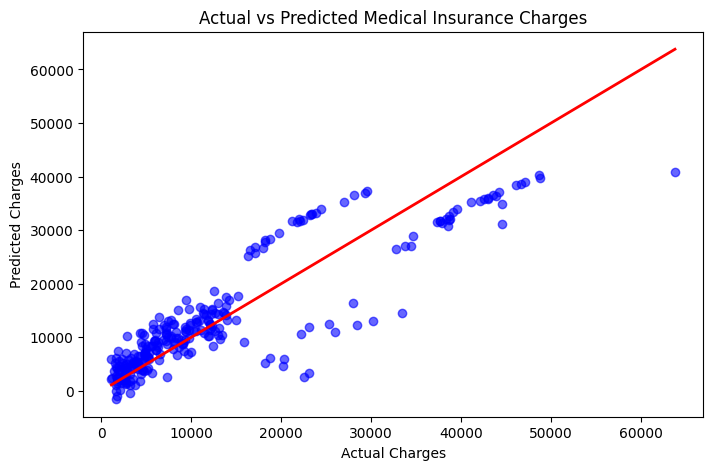

In [ ]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score: {r2:.4f}\n")

# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Medical Insurance Charges')
plt.show()

### Observations
1. The $R^2$ score indicates that the model accounts for a significant portion of the overall variance in medical insurance costs[cite: 1].
2. The scatter plot reveals a clear positive trend between actual and predicted charges, with predictions closely following the ideal reference line for lower to mid-range costs[cite: 1].
3. The model tends to underpredict charges for high-cost individuals, which corresponds to specific high-risk subgroups such as smokers with elevated BMIs[cite: 1].

---

### Conclusion
This assignment successfully deployed a Multiple Linear Regression model to predict medical insurance charges[cite: 1]. The primary key findings indicate that insurance costs are predominantly driven by a customer's smoking status, which serves as the most critical risk factor[cite: 1]. Additionally, an individual’s age and Body Mass Index (BMI) also significantly elevate the estimated insurance charges, whereas region and children have a lesser effect[cite: 1]. 

One notable limitation of applying Linear Regression to this specific medical dataset is its inherent assumption that all independent variables operate independently of one another[cite: 1]. In reality, health factors are often highly correlated. For example, the detrimental health effects of smoking are often compounded exponentially when combined with a high BMI. Because a basic linear model adds these features independently, it struggles to capture these complex, synergistic interactions, thereby limiting its predictive accuracy for high-risk patients.